In [10]:
import numpy as np
import os
import cv2
from scipy.spatial.transform import Rotation

filename = '2026-01-15_15-27-19_hand_eye_calibration.npz'  # 파일명

BASE_DIR = os.getcwd()
TARGET_DIR = os.path.join(BASE_DIR, 
                          "hand_eye_calibration", 
                          "data_log", 
                          "01-15",                          
                         )
data_path = os.path.join(TARGET_DIR, filename)

data = np.load(data_path)

tvecs = data['Target_tvecs']        # [count, id, tx, ty, tz] (cam->target, m)
rvecs = data['Target_rvecs']        # [count, rx, ry, rz]     (cam->target, Rodrigues rad)
gripper_pose = data['gripper_pose'] # [x,y,z,qx,qy,qz,qw]     (base->gripper, m + quat xyzw)

def rvec_to_R(rvec_xyz):
    rvec_xyz = np.array(rvec_xyz, dtype=np.float64).reshape(3, 1)
    Rm, _ = cv2.Rodrigues(rvec_xyz)
    return Rm

def quat_to_R(quat_xyzw):
    return Rotation.from_quat(quat_xyzw).as_matrix()

def invert_R_t(Rm, t):
    t = np.array(t, dtype=np.float64).reshape(3, 1)
    R_inv = Rm.T
    t_inv = -R_inv @ t
    return R_inv, t_inv

R_target2cam_list = []
t_target2cam_list = []
R_gripper2base_list = []
t_gripper2base_list = []

N = min(len(tvecs), len(rvecs), len(gripper_pose))
if N < 3:
    raise RuntimeError(f"Too few samples: N={N}")

for i in range(N):
    # --------------------------
    # (A) ArUco: stored cam->target  -> need target->cam
    # --------------------------
    rvec_ct = rvecs[i, 1:4]
    tvec_ct = tvecs[i, 2:5]

    R_ct = rvec_to_R(rvec_ct)
    t_ct = tvec_ct.reshape(3, 1)

    # ✅ invert: target->cam
    R_tc, t_tc = invert_R_t(R_ct, t_ct)

    R_target2cam_list.append(R_ct)
    t_target2cam_list.append(t_ct)

    # --------------------------
    # (B) Robot: stored base->gripper -> need gripper->base
    # --------------------------
    x, y, z, qx, qy, qz, qw = gripper_pose[i].astype(np.float64)

    R_bg = quat_to_R([qx, qy, qz, qw])
    t_bg = np.array([x, y, z], dtype=np.float64).reshape(3, 1)

    # ✅ invert: gripper->base
    R_gb, t_gb = invert_R_t(R_bg, t_bg)

    R_gripper2base_list.append(R_bg)
    t_gripper2base_list.append(t_bg)

# --------------------------
# OpenCV Hand-Eye Calibration
# --------------------------
R_cam2gripper, t_cam2gripper = cv2.calibrateHandEye(
    R_gripper2base_list, t_gripper2base_list,
    R_target2cam_list, t_target2cam_list,
    method=cv2.CALIB_HAND_EYE_TSAI
)

T_cam2gripper = np.eye(4, dtype=np.float64)
T_cam2gripper[:3, :3] = R_cam2gripper
T_cam2gripper[:3, 3] = t_cam2gripper.reshape(3)

T_gripper2cam = np.linalg.inv(T_cam2gripper)

R_gripper2cam, t_gripper2cam = invert_R_t(R_cam2gripper, t_cam2gripper)


print("===== Hand-Eye Calibration Result =====")
print(f"param file name : {filename}")
print("R_cam2gripper:\n", R_cam2gripper)
print("t_cam2gripper [m]:\n", t_cam2gripper.reshape(3))
print("\nT_cam2gripper:\n", T_cam2gripper)
print("\nT_gripper2cam:\n", T_gripper2cam)


# cv2 annotation of hand eye calibration is not the same as read
# cam2gripper = gripper frame based on camera(X)
#             = camera frame based on gripper(O)
# most of the following annotations follow the same rule, read with caution!




===== Hand-Eye Calibration Result =====
param file name : 2026-01-15_15-27-19_hand_eye_calibration.npz
R_cam2gripper:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
t_cam2gripper [m]:
 [0. 0. 0.]

T_cam2gripper:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

T_gripper2cam:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


[ERROR:0@13078.762] global calibration_handeye.cpp:335 calibrateHandEyeTsai Hand-eye calibration failed! Not enough informative motions--include larger rotations.


In [ ]:
len(tvecs)

13

/tmp/ipykernel_11084/132072888.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tx, ty, tz, rx, ry, rz, g_tx, g_ty, g_tz, g_qx, g_qy, g_qz, g_qw],


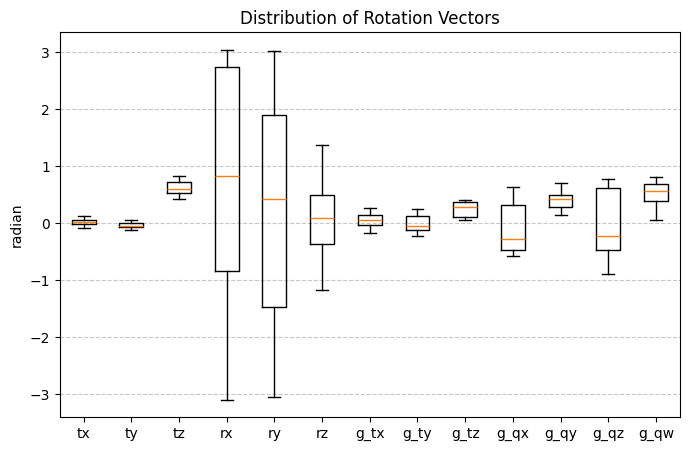

In [161]:
import matplotlib.pyplot as plt
import numpy as np

tx = tvecs[:, 2]
ty = tvecs[:, 3]
tz = tvecs[:, 4]
rx = rvecs[:, 1]
ry = rvecs[:, 2]
rz = rvecs[:, 3]
g_tx = gripper_pose[:, 0]
g_ty = gripper_pose[:, 1]
g_tz = gripper_pose[:, 2]
g_qx = gripper_pose[:, 3]
g_qy = gripper_pose[:, 4]
g_qz = gripper_pose[:, 5]
g_qw = gripper_pose[:, 6]

# boxplot 생성
plt.figure(figsize=(8, 5))
plt.boxplot([tx, ty, tz, rx, ry, rz, g_tx, g_ty, g_tz, g_qx, g_qy, g_qz, g_qw], 
            labels=['tx', 'ty', 'tz','rx', 'ry', 'rz', 'g_tx', 'g_ty', 'g_tz', 'g_qx', 'g_qy', 'g_qz', 'g_qw'])
plt.title('Distribution of Rotation Vectors')
plt.ylabel('radian')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

#used 50 images taken in same robot & marker positions

/tmp/ipykernel_11084/3956407544.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tx, ty, tz, rx, ry, rz, g_tx, g_ty, g_tz, g_qx, g_qy, g_qz, g_qw],


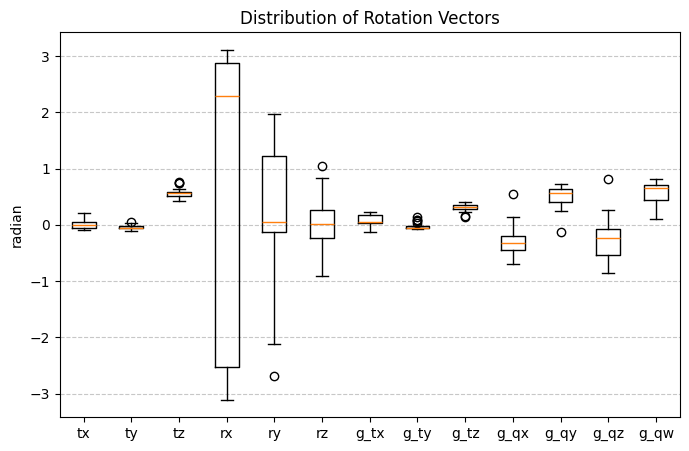

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tx = tvecs[:, 2]
ty = tvecs[:, 3]
tz = tvecs[:, 4]
rx = rvecs[:, 1]
ry = rvecs[:, 2]
rz = rvecs[:, 3]
g_tx = gripper_pose[:, 0]
g_ty = gripper_pose[:, 1]
g_tz = gripper_pose[:, 2]
g_qx = gripper_pose[:, 3]
g_qy = gripper_pose[:, 4]
g_qz = gripper_pose[:, 5]
g_qw = gripper_pose[:, 6]

# boxplot 생성
plt.figure(figsize=(8, 5))
plt.boxplot([tx, ty, tz, rx, ry, rz, g_tx, g_ty, g_tz, g_qx, g_qy, g_qz, g_qw], 
            labels=['tx', 'ty', 'tz','rx', 'ry', 'rz', 'g_tx', 'g_ty', 'g_tz', 'g_qx', 'g_qy', 'g_qz', 'g_qw'])
plt.title('Distribution of Rotation Vectors')
plt.ylabel('radian')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

#data of first merged

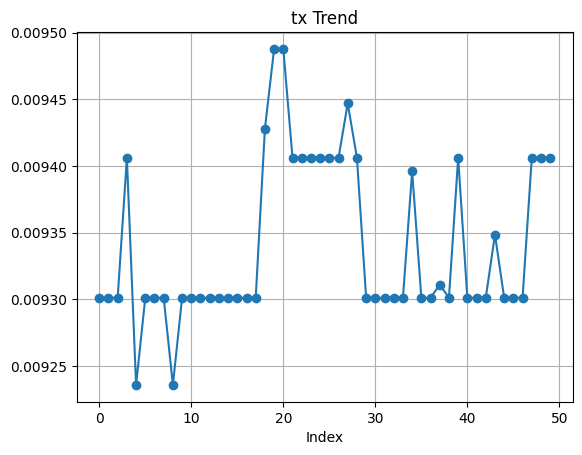

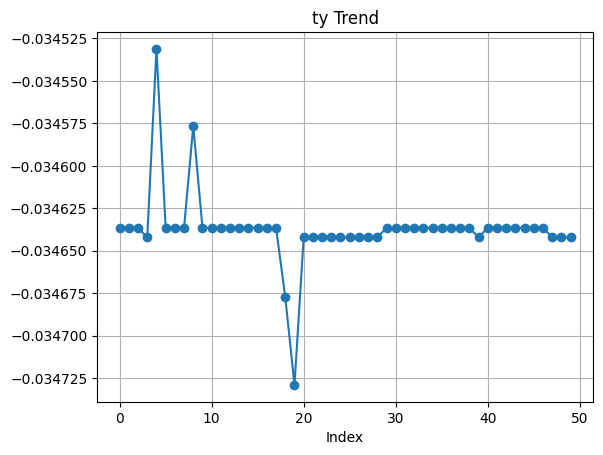

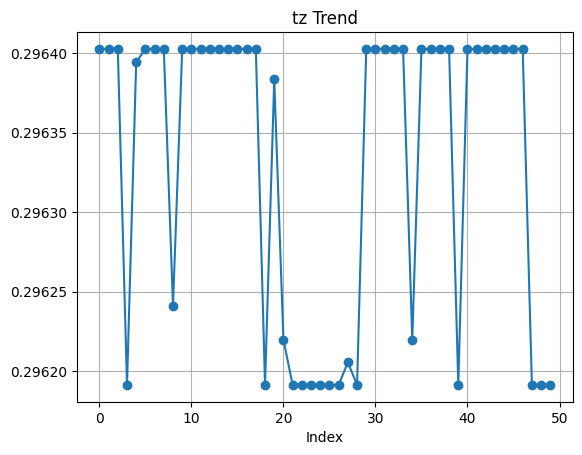

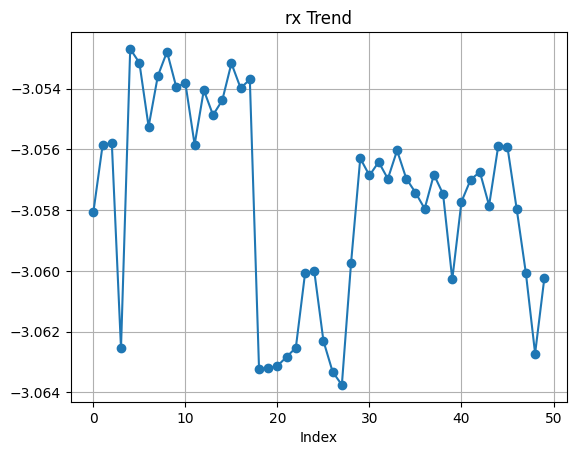

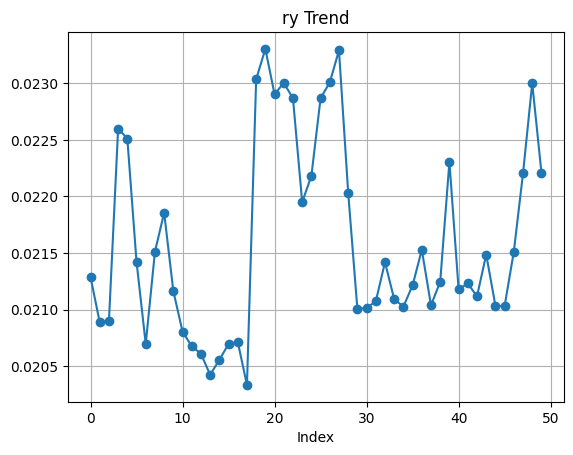

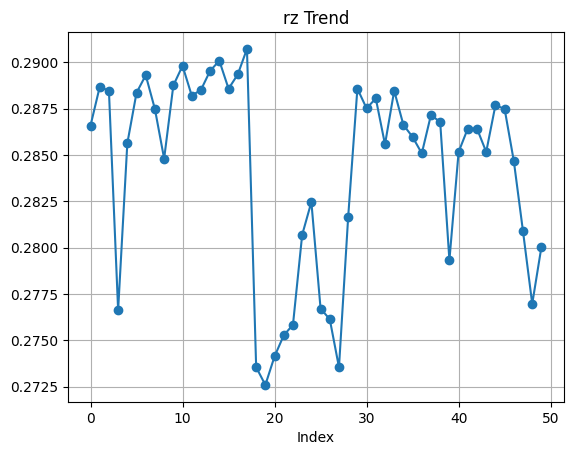

In [16]:
import matplotlib.pyplot as plt
import numpy as np

tx = tvecs[:, 2]
ty = tvecs[:, 3]
tz = tvecs[:, 4]
rx = rvecs[:, 1]
ry = rvecs[:, 2]
rz = rvecs[:, 3]
g_tx = gripper_pose[:, 0]
g_ty = gripper_pose[:, 1]
g_tz = gripper_pose[:, 2]
g_qx = gripper_pose[:, 3]
g_qy = gripper_pose[:, 4]
g_qz = gripper_pose[:, 5]
g_qw = gripper_pose[:, 6]

name = 'target_rvec_rz'

plt.plot(tx, marker='o')
plt.title('tx Trend')
plt.xlabel('Index')
plt.grid(True)
plt.show()


plt.plot(ty, marker='o')
plt.title('ty Trend')
plt.xlabel('Index')
plt.grid(True)
plt.show()


plt.plot(tz, marker='o')
plt.title('tz Trend')
plt.xlabel('Index')
plt.grid(True)
plt.show()

plt.plot(rx, marker='o')
plt.title('rx Trend')
plt.xlabel('Index')
plt.grid(True)
plt.show()


plt.plot(ry, marker='o')
plt.title('ry Trend')
plt.xlabel('Index')
plt.grid(True)
plt.show()


plt.plot(rz, marker='o')
plt.title('rz Trend')
plt.xlabel('Index')
plt.grid(True)
plt.show()

keys: ['Target_tvecs', 'Target_rvecs', 'gripper_pose']
tvecs.shape: (100, 5) dtype: float64
rvecs.shape: (100, 4) dtype: float64
gripper_pose.shape: (100, 7) dtype: float64
tvecs[0]: [ 1.          3.         -0.03110076  0.05766314  0.62869613]


In [157]:
import numpy as np

npz_path = "/home/addinedu/calibration/hand_eye_calibration/01-14/2026-01-14_10-55-52_hand_eye_calibration.npz"
data = np.load(npz_path)

tvecs = data["Target_tvecs"]
rvecs = data["Target_rvecs"]
gripper = data["gripper_pose"]

idx = 5# 👈 확인하고 싶은 index

print("=== Target tvec ===")
print(tvecs[idx])

print("\n=== Target rvec ===")
print(rvecs[idx])

print("\n=== Gripper pose ===")
print(gripper[idx])


=== Target tvec ===
[ 1.00000000e+00  3.00000000e+00 -2.66237192e-04 -4.67667376e-02
  4.94398324e-01]

=== Target rvec ===
[ 1.          3.04329003  0.37416578 -0.37058341]

=== Gripper pose ===
[ 0.1423     -0.1365      0.3587     -0.44784891  0.49435334 -0.28644691
  0.68774581]


In [158]:
remove_indices = [5]  # 👈 outlier index 리스트

mask = np.ones(len(tvecs), dtype=bool)
mask[remove_indices] = False

np.savez(
    "2026-01-14_10-55-52_hand_eye_calibration_layer_1_filtered.npz",
    Target_tvecs=tvecs[mask],
    Target_rvecs=rvecs[mask],
    gripper_pose=gripper[mask]
)

print(f"Removed indices: {remove_indices}")





Removed indices: [5]
